In [1]:
from moabb.datasets import BNCI2014_001
from moabb.paradigms import LeftRightImagery
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from scipy.signal import welch

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/home/piotr/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = BNCI2014_001()
paradigm = LeftRightImagery()

X, y, meta = paradigm.get_data(dataset=dataset, subjects=[1])

print(X.shape)
print(y[:10])
print(meta.head())

(288, 22, 1001)
['right_hand' 'left_hand' 'left_hand' 'right_hand' 'right_hand'
 'left_hand' 'left_hand' 'left_hand' 'right_hand' 'right_hand']
   subject session run
0        1  0train   0
1        1  0train   0
2        1  0train   0
3        1  0train   0
4        1  0train   0


In [3]:
print(X.shape)
print(Counter(y))
print(meta["session"].value_counts())
print(meta["run"].value_counts())

(288, 22, 1001)
Counter({np.str_('right_hand'): 144, np.str_('left_hand'): 144})
session
0train    144
1test     144
Name: count, dtype: int64
run
0    48
1    48
2    48
3    48
4    48
5    48
Name: count, dtype: int64


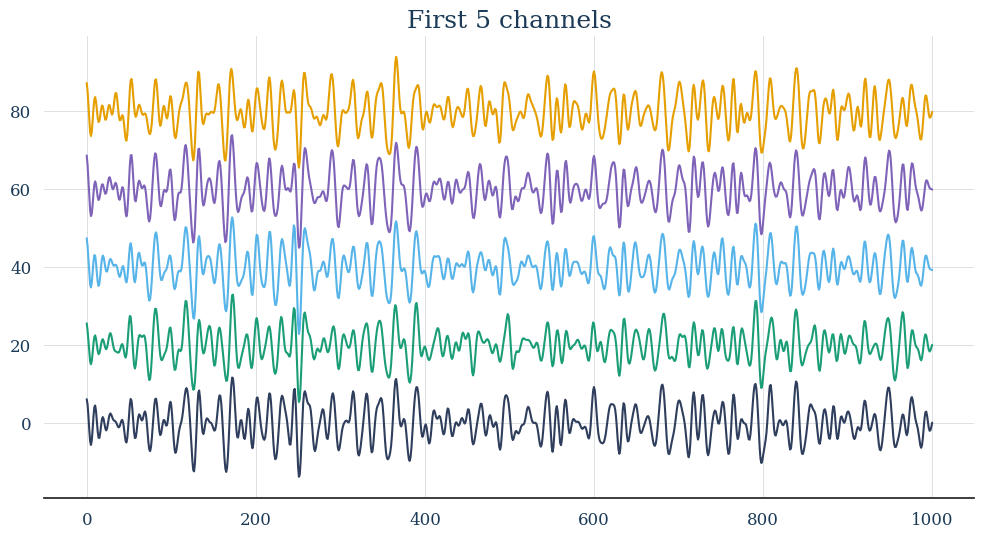

In [4]:
trial = X[0]

plt.figure(figsize=(12,6))
for i in range(5):
    plt.plot(trial[i] + i*20)

plt.title("First 5 channels")
plt.show()

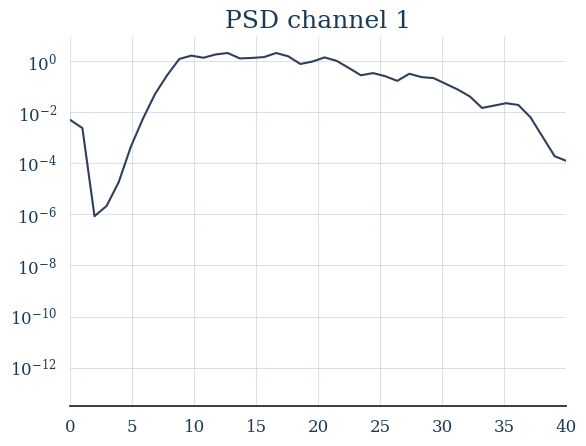

In [5]:
fs = 250

f, pxx = welch(X[0,0], fs=fs)

plt.semilogy(f, pxx)
plt.xlim(0,40)
plt.title("PSD channel 1")
plt.show()

In [6]:
Counter(y)

Counter({np.str_('right_hand'): 144, np.str_('left_hand'): 144})

In [7]:
np.isnan(X).sum()

np.int64(0)

(array([ 5., 11.,  7., 17., 19., 25., 25., 29., 24., 19., 19., 15., 16.,
        12.,  7.,  8.,  5., 10.,  2.,  2.,  2.,  2.,  2.,  0.,  0.,  1.,
         1.,  2.,  0.,  1.]),
 array([14.04558491, 14.92907152, 15.81255812, 16.69604473, 17.57953134,
        18.46301794, 19.34650455, 20.22999115, 21.11347776, 21.99696437,
        22.88045097, 23.76393758, 24.64742419, 25.53091079, 26.4143974 ,
        27.29788401, 28.18137061, 29.06485722, 29.94834383, 30.83183043,
        31.71531704, 32.59880364, 33.48229025, 34.36577686, 35.24926346,
        36.13275007, 37.01623668, 37.89972328, 38.78320989, 39.6666965 ,
        40.5501831 ]),
 <BarContainer object of 30 artists>)

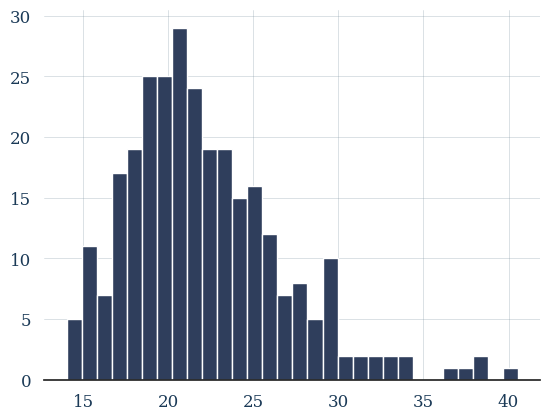

In [8]:
trial_var = X.var(axis=(1,2))
plt.hist(trial_var, bins=30)